### 1. Setup & Data Loading

In [1]:
#Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


sns.set(style="whitegrid", context="notebook")


In [2]:
#Load data
DATA_PATH = "student_habits_performance.csv"


df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


### 2. Initial Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [5]:
df.describe(include="object").T

,count,unique,top,freq
student_id,1000,1000,S1000,1
gender,1000,3,Female,481
part_time_job,1000,2,No,785
diet_quality,1000,3,Fair,437
parental_education_level,909,3,High School,392
internet_quality,1000,3,Good,447
extracurricular_participation,1000,2,No,682


In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [7]:
#If student_id column exists, delete it because it has no predictive value.

if "student_id" in df.columns:
    df = df.drop(columns=["student_id"])

print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


### 3. Missing Value Handling

In [8]:
# Check for missing values
df.isna().sum()

age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [9]:
#Detecting mode value for missing value handling
mode_value = df["parental_education_level"].mode()[0]
print("Most frequent parental education level: ", mode_value)

Most frequent parental education level:  High School


In [10]:
#Missing value handling (mode imputation)
df["parental_education_level"] = df["parental_education_level"].fillna(mode_value)

In [11]:
df["parental_education_level"].isna().sum()

0

### 4. Exploratory Data Analysis (EDA)

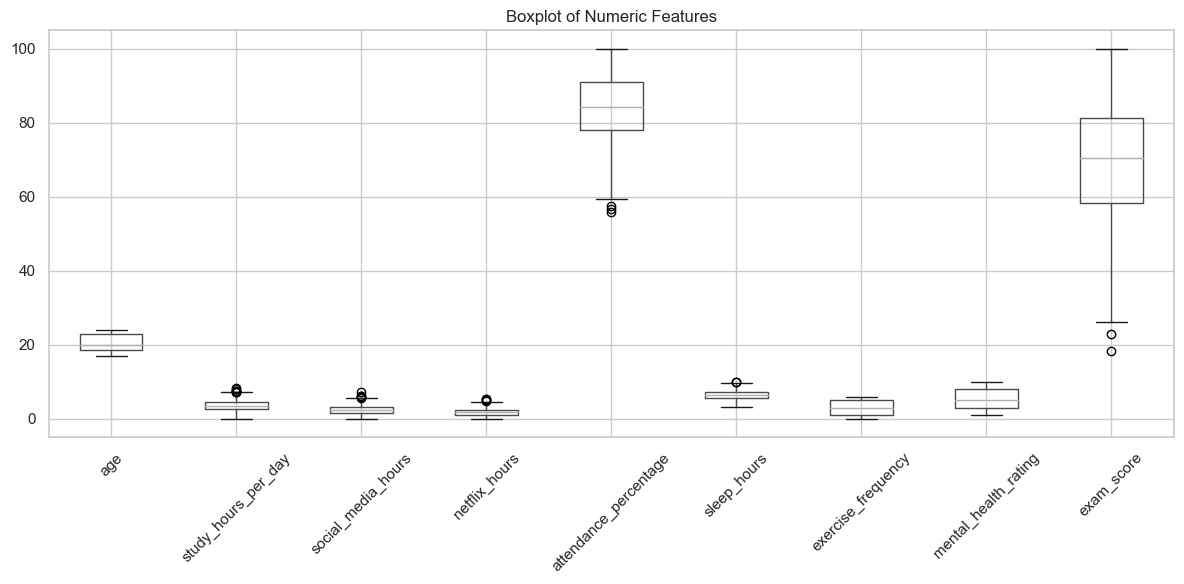

In [12]:
#Outlier analysis using boxplots

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numeric Features")
plt.tight_layout()
plt.show()

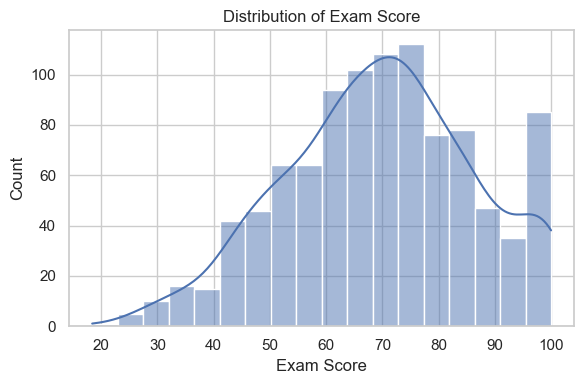

In [13]:
# Target variable (exam_score) distribution

plt.figure(figsize=(6,4))
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

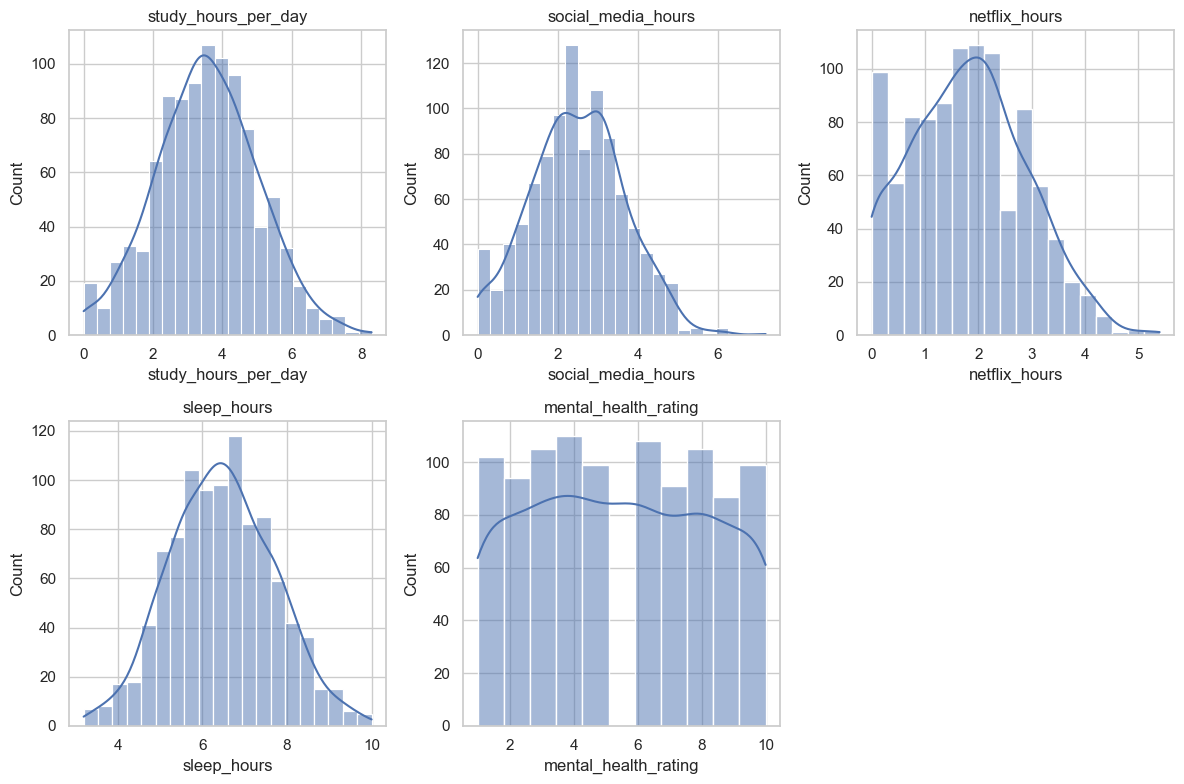

In [14]:
# Feature distribution
features_to_plot = ["study_hours_per_day",
                    "social_media_hours",
                    "netflix_hours",
                    "sleep_hours",
                    "mental_health_rating"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


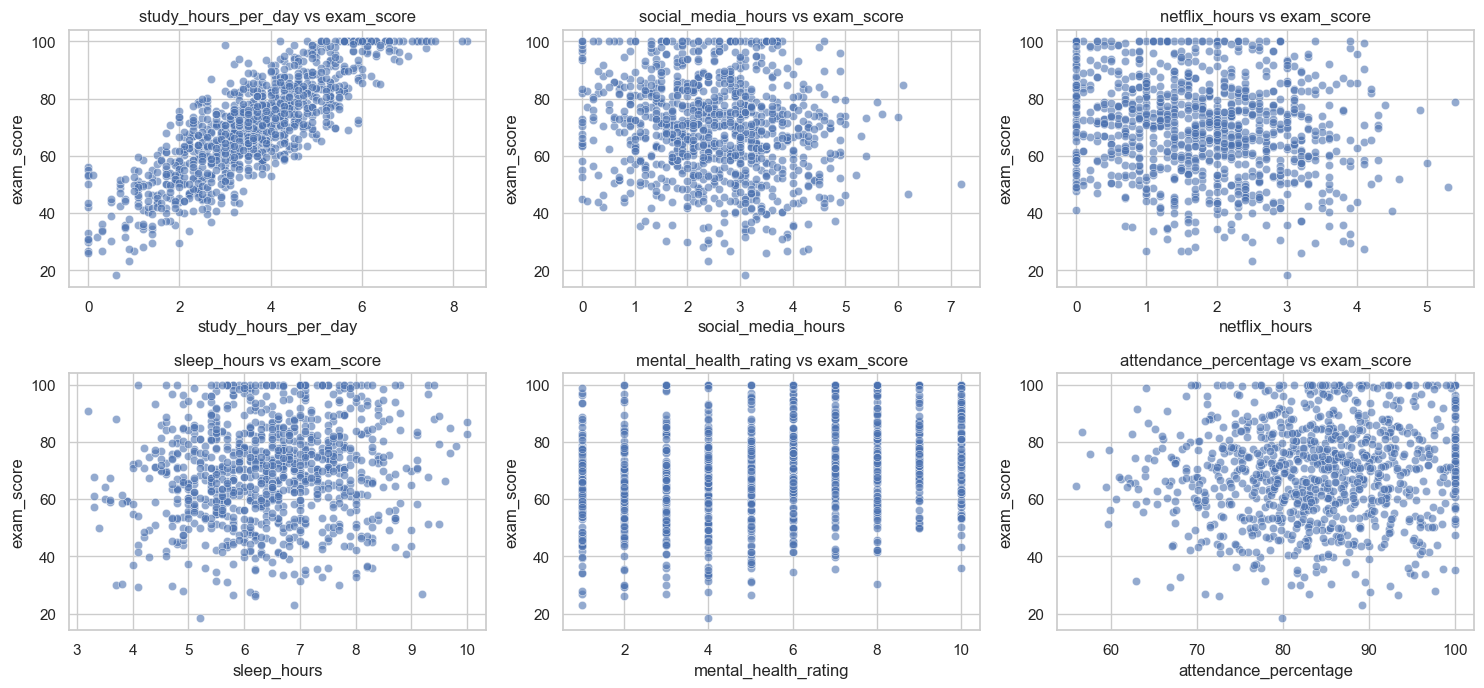

In [15]:
# Scatter plots for the main relationships in our hypotheses
scatter_features = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "sleep_hours",
    "mental_health_rating",
    "attendance_percentage"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(scatter_features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(data=df, x=col, y="exam_score", alpha=0.6)
    plt.title(f"{col} vs exam_score")
plt.tight_layout()
plt.show()

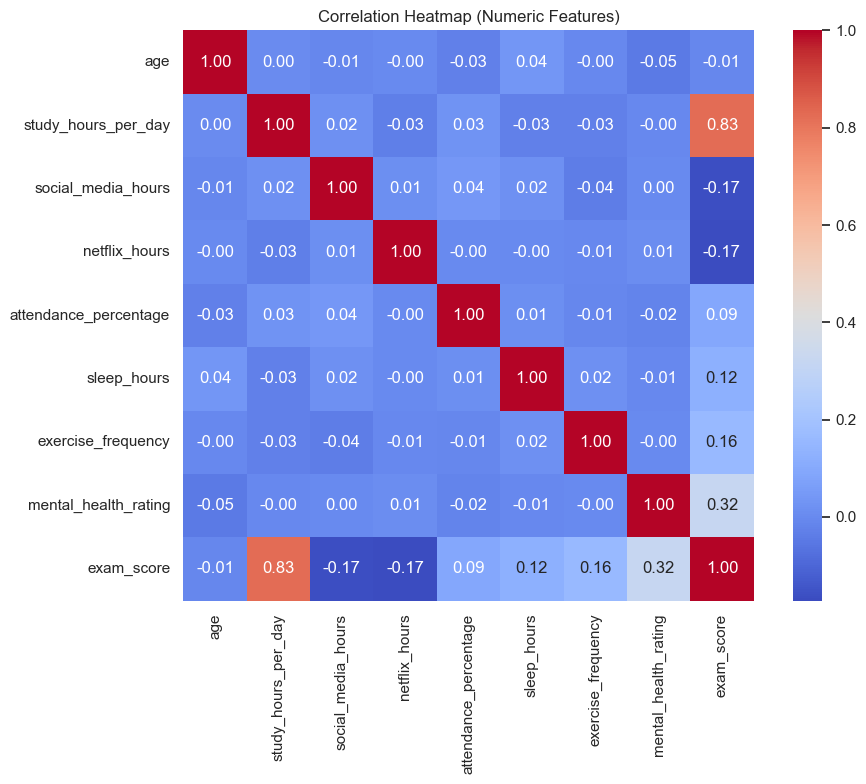

In [16]:
# Correlation matrix & Heatmap
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [17]:
# Sorted correlations with exam_score
corr_with_target = corr["exam_score"].sort_values(ascending=False)
corr_with_target

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64

### 5. Encoding Categorical Variables 

In [18]:
df_encoded = df.copy()

In [19]:
binary_map = {"Yes": 1, "No": 0}

In [20]:
if "part_time_job" in df_encoded.columns:
    df_encoded["part_time_job"] = df_encoded["part_time_job"].map(binary_map)

if "extracurricular_participation" in df_encoded.columns:
    df_encoded["extracurricular_participation"] = df_encoded["extracurricular_participation"].map(binary_map)


In [21]:
# Diet quality: Poor < Fair < Good
diet_map = {"Poor": 0, "Fair": 1, "Good": 2}
if "diet_quality" in df_encoded.columns:
    df_encoded["diet_quality"] = df_encoded["diet_quality"].map(diet_map)


In [22]:
# Gender, Internet quality, Parental education -> ONE-HOT Encoding
one_hot_cols = [
    col for col in ["gender", "internet_quality", "parental_education_level"]
    if col in df_encoded.columns
]

df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)

In [23]:
dummy_cols = [col for col in df_encoded.columns if df_encoded[col].dtype == "bool"]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

df_encoded.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,mental_health_rating,extracurricular_participation,exam_score,gender_Male,gender_Other,internet_quality_Good,internet_quality_Poor,parental_education_level_High School,parental_education_level_Master
0,23,0.0,1.2,1.1,0,85.0,8.0,1,6,8,1,56.2,0,0,0,0,0,1
1,20,6.9,2.8,2.3,0,97.3,4.6,2,6,8,0,100.0,0,0,0,0,1,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0,1,1,0,34.3,1,0,0,1,1,0
3,23,1.0,3.9,1.0,0,71.0,9.2,0,4,1,1,26.8,0,0,1,0,0,1
4,19,5.0,4.4,0.5,0,90.9,4.9,1,3,1,0,66.4,0,0,1,0,0,1


In [24]:
df_encoded.dtypes

age                                       int64
study_hours_per_day                     float64
social_media_hours                      float64
netflix_hours                           float64
part_time_job                             int64
attendance_percentage                   float64
sleep_hours                             float64
diet_quality                              int64
exercise_frequency                        int64
mental_health_rating                      int64
extracurricular_participation             int64
exam_score                              float64
gender_Male                               int32
gender_Other                              int32
internet_quality_Good                     int32
internet_quality_Poor                     int32
parental_education_level_High School      int32
parental_education_level_Master           int32
dtype: object

In [25]:
data_card = pd.DataFrame({
    "n_rows": [df.shape[0]],
    "n_columns_raw": [df.shape[1]],
    "n_columns_encoded": [df_encoded.shape[1]],
    "target": ["exam_score"],
    "n_numeric_raw": [df.select_dtypes(include="number").shape[1]],
    "n_categorical_raw": [df.select_dtypes(exclude="number").shape[1]],
})

print("\nData card summary:")
display(data_card)

print("\nBasic statistics of target (exam_score):")
display(df["exam_score"].describe())


Data card summary:


,n_rows,n_columns_raw,n_columns_encoded,target,n_numeric_raw,n_categorical_raw
0,1000,15,18,exam_score,9,6



Basic statistics of target (exam_score):


count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64

### 6. Feature Engineering

In [26]:
df_fe = df_encoded.copy()

In [27]:
#New feature: total_screen_time as the sum of social_media_hours and netflix_hours

df_fe["total_screen_time"] = df_fe["social_media_hours"] + df_fe["netflix_hours"]

In [28]:
print("\nSimple engineered features head:")

display(df_fe[[

    "social_media_hours",
    "netflix_hours",
    "total_screen_time",
    
]].head())


Simple engineered features head:


,social_media_hours,netflix_hours,total_screen_time
0,1.2,1.1,2.3
1,2.8,2.3,5.1
2,3.1,1.3,4.4
3,3.9,1.0,4.9
4,4.4,0.5,4.9


In [29]:
# Correlations between study_hours_per_day and exam_score

corr_study_exam = df_fe[["study_hours_per_day"] + ["exam_score"]].corr()["exam_score"].drop("exam_score")

print(corr_study_exam)

study_hours_per_day    0.825419
Name: exam_score, dtype: float64


In [30]:
# Correlations between behavior-related features and exam_score

corr_screen_exam = df_fe[["total_screen_time"] + ["exam_score"]].corr()["exam_score"].drop("exam_score")

print(corr_screen_exam)

total_screen_time   -0.237631
Name: exam_score, dtype: float64


In [31]:
env_features = []

In [32]:
# one-hot internet quality sütunları
env_features += [col for col in df_fe.columns
                 if col.startswith("internet_quality_")]

# one-hot parental education sütunları
env_features += [col for col in df_fe.columns
                 if col.startswith("parental_education_level_")]

In [33]:
print("Environmental feature columns:", env_features)

Environmental feature columns: ['internet_quality_Good', 'internet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master']


In [34]:
env_corr = df_fe[env_features + ["exam_score"]].corr()["exam_score"].drop("exam_score")

print("\nEnvironmental feature correlations with exam_score:")
print(env_corr)


Environmental feature correlations with exam_score:
internet_quality_Good                  -0.050804
internet_quality_Poor                   0.003016
parental_education_level_High School    0.002143
parental_education_level_Master        -0.040177
Name: exam_score, dtype: float64


In [35]:
# Separate positive and negative environmental correlations

pos_env_corr = env_corr[env_corr > 0]
neg_env_corr = env_corr[env_corr < 0]

In [36]:
# Normalize environmental correlations to obtain relative weights

if len(pos_env_corr) > 0:
    pos_env_weights = pos_env_corr / pos_env_corr.max()
else:
    pos_env_weights = pos_env_corr

if len(neg_env_corr) > 0:
    neg_env_weights = neg_env_corr / abs(neg_env_corr.min())
else:
    neg_env_weights = neg_env_corr

In [37]:
print("\nEnvironmental positive weights (from correlations):")
print(pos_env_weights)

print("\nEnvironmental negative weights (from correlations):")
print(neg_env_weights)


Environmental positive weights (from correlations):
internet_quality_Poor                   1.000000
parental_education_level_High School    0.710539
Name: exam_score, dtype: float64

Environmental negative weights (from correlations):
internet_quality_Good             -1.000000
parental_education_level_Master   -0.790832
Name: exam_score, dtype: float64


In [38]:
# Build environmental_score similarly: weighted sum of positive factors minus weighted negative factors (if any)

env_score = pd.Series(0.0, index=df_fe.index)

In [39]:
for feat, w in pos_env_weights.items():
    env_score += w * df_fe[feat]

for feat, w in neg_env_weights.items():
    env_score -= abs(w) * df_fe[feat]

df_fe["environmental_score"] = env_score

In [40]:
print("\nCorrelation between environmental_score and exam_score:")
print(df_fe[["environmental_score", "exam_score"]].corr()["exam_score"])
display(df_fe[["environmental_score", "exam_score"]].head())


Correlation between environmental_score and exam_score:
environmental_score    0.041818
exam_score             1.000000
Name: exam_score, dtype: float64


,environmental_score,exam_score
0,-0.790832,56.2
1,0.710539,100.0
2,1.710539,34.3
3,-1.790832,26.8
4,-1.790832,66.4


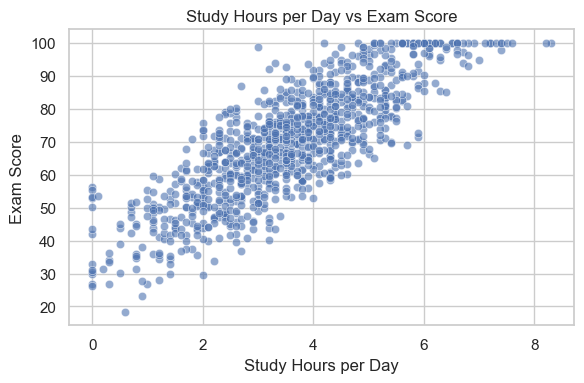

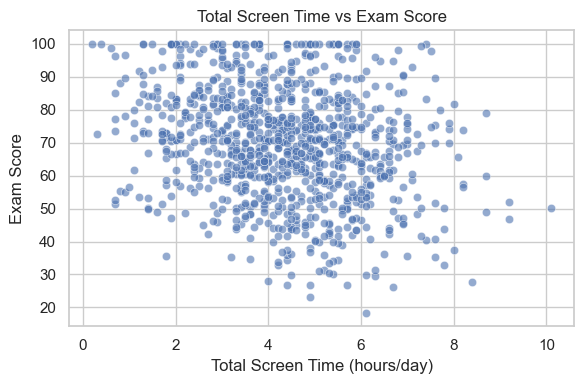

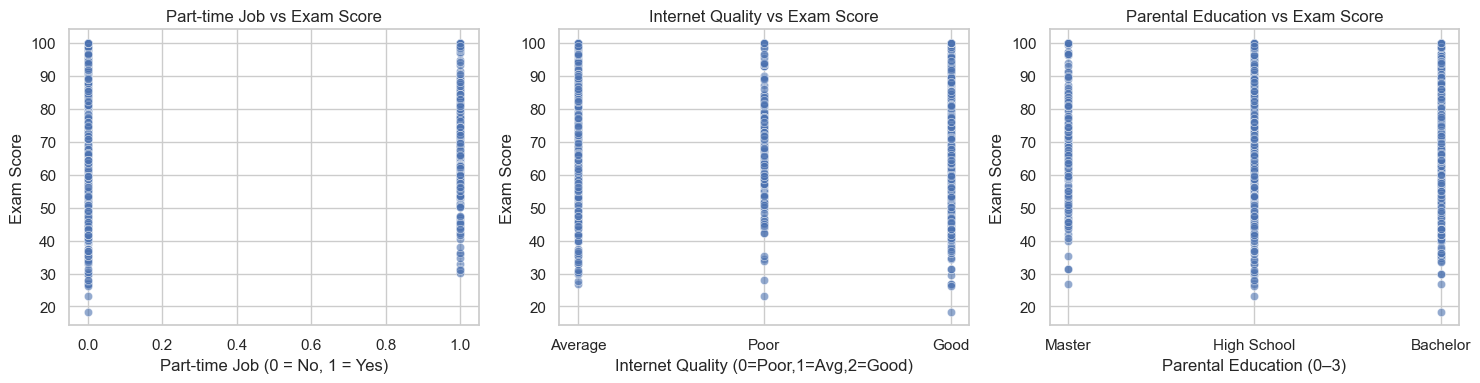

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")


# 1) Study hours per day vs exam_score (correlation plot)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_fe,
                x="study_hours_per_day",
                y="exam_score",
                alpha=0.6)
plt.title("Study Hours per Day vs Exam Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

# 2) Total screen time vs exam_score (correlation plot)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_fe,
                x="total_screen_time",
                y="exam_score",
                alpha=0.6)
plt.title("Total Screen Time vs Exam Score")
plt.xlabel("Total Screen Time (hours/day)")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()


# 3) Environmental features vs exam_score (correlation plots)
#    - part_time_job
#    - internet_quality
#    - parental_education_level

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# a) Part-time job vs exam_score
sns.scatterplot(
    data=df_fe,
    x="part_time_job",
    y="exam_score",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Part-time Job vs Exam Score")
axes[0].set_xlabel("Part-time Job (0 = No, 1 = Yes)")
axes[0].set_ylabel("Exam Score")

# b) Internet quality vs exam_score
sns.scatterplot(
    data=df,
    x="internet_quality",
    y="exam_score",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Internet Quality vs Exam Score")
axes[1].set_xlabel("Internet Quality (0=Poor,1=Avg,2=Good)")
axes[1].set_ylabel("Exam Score")

# c) Parental education vs exam_score
sns.scatterplot(
    data=df,
    x="parental_education_level",
    y="exam_score",
    alpha=0.6,
    ax=axes[2]
)
axes[2].set_title("Parental Education vs Exam Score")
axes[2].set_xlabel("Parental Education (0–3)")
axes[2].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()


### 7. Split Dataset & Modeling and Evaluation

In [54]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sns.set(style="whitegrid", context="notebook")

In [55]:
# Feature / target 
feature_cols = [col for col in df_fe.columns if col != "exam_score"]
X = df_fe[feature_cols]
y = df_fe["exam_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

# This threshold will be used to build a risk flag for low-performing students
RISK_THRESHOLD = 60

results = []


Train shape: (800, 19) Test shape: (200, 19)


In [56]:
def regression_report(y_true, y_pred, name, store=True, risk_threshold=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} performance (regression):")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R^2 : {r2:.3f}")
    print("-" * 40)
    
    acc = prec = rec = f1 = None

    # If a risk threshold is given, compute classification metrics as well
    if risk_threshold is not None:
        y_true_risk = (y_true < risk_threshold).astype(int)
        y_pred_risk = (y_pred < risk_threshold).astype(int)

        acc = accuracy_score(y_true_risk, y_pred_risk)
        prec = precision_score(y_true_risk, y_pred_risk, zero_division=0)
        rec = recall_score(y_true_risk, y_pred_risk, zero_division=0)
        f1 = f1_score(y_true_risk, y_pred_risk, zero_division=0)

        print(f"{name} performance (risk flag, threshold={risk_threshold}):")
        print(f"  Accuracy : {acc:.3f}")
        print(f"  Precision: {prec:.3f}")
        print(f"  Recall   : {rec:.3f}")
        print(f"  F1-score : {f1:.3f}")

    print("-" * 50)

    if store:
        results.append({
            "model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Risk_Accuracy": acc,
            "Risk_Precision": prec,
            "Risk_Recall": rec,
            "Risk_F1": f1,
        })

    return mae, rmse, r2, acc, prec, rec, f1

In [57]:
best_model_name = None
best_model = None
best_mae = np.inf

In [58]:
# Baseline model

baseline_pred = np.repeat(y_train.mean(), len(y_test))
mae_base, _, _, _, _, _, _ = regression_report(
    y_test, baseline_pred, "Baseline (mean predictor)",
    store=True, risk_threshold=RISK_THRESHOLD
)
# baseline is only for reference; we do not use it as best_model


Baseline (mean predictor) performance (regression):
  MAE : 12.38
  RMSE: 16.05
  R^2 : -0.005
----------------------------------------
Baseline (mean predictor) performance (risk flag, threshold=60):
  Accuracy : 0.745
  Precision: 0.000
  Recall   : 0.000
  F1-score : 0.000
--------------------------------------------------


In [59]:
# Linear Regression

# Pipeline: StandardScaler + LinearRegression
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

mae_lr, _, _, _, _, _, _ = regression_report(
    y_test, y_pred_lr, "Linear Regression (scaled)",
    store=True, risk_threshold=RISK_THRESHOLD
)

if mae_lr < best_mae:
    best_mae = mae_lr
    best_model_name = "Linear Regression (scaled)"
    best_model = lr_pipe

Linear Regression (scaled) performance (regression):
  MAE : 4.16
  RMSE: 5.12
  R^2 : 0.898
----------------------------------------
Linear Regression (scaled) performance (risk flag, threshold=60):
  Accuracy : 0.950
  Precision: 0.887
  Recall   : 0.922
  F1-score : 0.904
--------------------------------------------------


In [60]:
#Random Forest (baseline)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf, _, _, _, _, _, _ = regression_report(
    y_test, y_pred_rf, "Random Forest (baseline)",
    store=True, risk_threshold=RISK_THRESHOLD
)

if mae_rf < best_mae:
    best_mae = mae_rf
    best_model_name = "Random Forest (baseline)"
    best_model = rf


Random Forest (baseline) performance (regression):
  MAE : 4.95
  RMSE: 6.09
  R^2 : 0.855
----------------------------------------
Random Forest (baseline) performance (risk flag, threshold=60):
  Accuracy : 0.935
  Precision: 0.852
  Recall   : 0.902
  F1-score : 0.876
--------------------------------------------------


In [61]:
#XGBoost Regressor 

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb, _, _, _, _, _, _ = regression_report(
    y_test, y_pred_xgb, "XGBoost",
    store=True, risk_threshold=RISK_THRESHOLD
)

if mae_xgb < best_mae:
    best_mae = mae_xgb
    best_model_name = "XGBoost"
    best_model = xgb


XGBoost performance (regression):
  MAE : 4.66
  RMSE: 5.67
  R^2 : 0.875
----------------------------------------
XGBoost performance (risk flag, threshold=60):
  Accuracy : 0.935
  Precision: 0.828
  Recall   : 0.941
  F1-score : 0.881
--------------------------------------------------


In [62]:
# CatBoost Regressor

cb = CatBoostRegressor(
    depth=6,
    learning_rate=0.05,
    n_estimators=300,
    random_state=42,
    verbose=False
)
cb.fit(X_train, y_train)
y_pred_cb = cb.predict(X_test)

mae_cb, _, _, _, _, _, _ = regression_report(
    y_test, y_pred_cb, "CatBoost",
    store=True, risk_threshold=RISK_THRESHOLD
)

if mae_cb < best_mae:
    best_mae = mae_cb
    best_model_name = "CatBoost"
    best_model = cb

CatBoost performance (regression):
  MAE : 4.19
  RMSE: 5.18
  R^2 : 0.895
----------------------------------------
CatBoost performance (risk flag, threshold=60):
  Accuracy : 0.945
  Precision: 0.870
  Recall   : 0.922
  F1-score : 0.895
--------------------------------------------------


In [63]:
#Random Forest (tuned)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nRandom Forest hyperparameter tuning:")
print("  Best params:", grid_search.best_params_)
print("  Best CV MAE:", -grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

mae_rf_tuned, _, _, _, _, _, _ = regression_report(
    y_test, y_pred_best_rf, "Random Forest (tuned)",
    store=True, risk_threshold=RISK_THRESHOLD
)

if mae_rf_tuned < best_mae:
    best_mae = mae_rf_tuned
    best_model_name = "Random Forest (tuned)"
    best_model = best_rf


Random Forest hyperparameter tuning:
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV MAE: 5.341941365586251
Random Forest (tuned) performance (regression):
  MAE : 4.95
  RMSE: 6.09
  R^2 : 0.855
----------------------------------------
Random Forest (tuned) performance (risk flag, threshold=60):
  Accuracy : 0.935
  Precision: 0.852
  Recall   : 0.902
  F1-score : 0.876
--------------------------------------------------


### 8. Cross-Validation and Model Comparison

In [64]:
#Cross-Validation for LR + RF + XGB + CB

print("\n5-fold cross-validation (MAE, mean ± std):")

# Linear Regression
lr_cv_scores = cross_val_score(
    lr_pipe, X, y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"  Linear Regression : {-lr_cv_scores.mean():.2f} ± {lr_cv_scores.std():.2f}")

# Tuned Random Forest
rf_cv_scores = cross_val_score(
    best_rf, X, y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"  Random Forest     : {-rf_cv_scores.mean():.2f} ± {rf_cv_scores.std():.2f}")

# XGBoost
xgb_cv_scores = cross_val_score(
    xgb, X, y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"  XGBoost           : {-xgb_cv_scores.mean():.2f} ± {xgb_cv_scores.std():.2f}")

# CatBoost
cb_cv_scores = cross_val_score(
    cb, X, y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"  CatBoost          : {-cb_cv_scores.mean():.2f} ± {cb_cv_scores.std():.2f}")



5-fold cross-validation (MAE, mean ± std):
  Linear Regression : 4.30 ± 0.16
  Random Forest     : 5.02 ± 0.30
  XGBoost           : 4.63 ± 0.21
  CatBoost          : 4.35 ± 0.19


In [65]:
# MODEL COMPARISON - EVALUATION MATRIX

results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values("MAE")
)

print("\nModel comparison on TEST set (evaluation matrix):")
display(
    results_df.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}",
            "Risk_Accuracy": "{:.3f}",
            "Risk_Precision": "{:.3f}",
            "Risk_Recall": "{:.3f}",
            "Risk_F1": "{:.3f}",
        }
    )
)

print(f"\nBest model on test set (by MAE): {best_model_name}  (MAE = {best_mae:.2f})")



Model comparison on TEST set (evaluation matrix):


,MAE,RMSE,R2,Risk_Accuracy,Risk_Precision,Risk_Recall,Risk_F1
model,,,,,,,
Linear Regression (scaled),4.16,5.12,0.898,0.950,0.887,0.922,0.904
CatBoost,4.19,5.18,0.895,0.945,0.870,0.922,0.895
XGBoost,4.66,5.67,0.875,0.935,0.828,0.941,0.881
Random Forest (baseline),4.95,6.09,0.855,0.935,0.852,0.902,0.876
Random Forest (tuned),4.95,6.09,0.855,0.935,0.852,0.902,0.876
Baseline (mean predictor),12.38,16.05,-0.005,0.745,0.000,0.000,0.000



Best model on test set (by MAE): Linear Regression (scaled)  (MAE = 4.16)


### 9. Risk Flag for Low-Performing Students


Final risk flag metrics (BEST model):
  Best model : Linear Regression (scaled)
  Threshold  : 60
  Accuracy   : 0.950
  Precision  : 0.887
  Recall     : 0.922
  F1-score   : 0.904

Confusion matrix [[TN, FP], [FN, TP]]:
[[143   6]
 [  4  47]]

Classification report:
              precision    recall  f1-score   support

 Not at risk       0.97      0.96      0.97       149
     At risk       0.89      0.92      0.90        51

    accuracy                           0.95       200
   macro avg       0.93      0.94      0.94       200
weighted avg       0.95      0.95      0.95       200



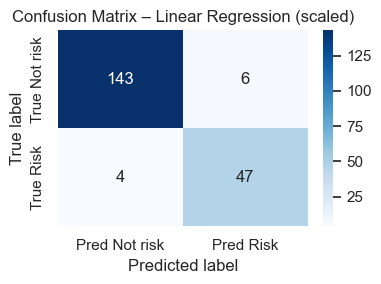

In [69]:
# RISK FLAG – CONFUSION MATRIX AND DETAILED METRICS

# Use the BEST model to build the final risk flag
y_pred_best = best_model.predict(X_test)
y_true_risk = (y_test < RISK_THRESHOLD).astype(int)
y_pred_risk = (y_pred_best < RISK_THRESHOLD).astype(int)

cm = confusion_matrix(y_true_risk, y_pred_risk)
acc = accuracy_score(y_true_risk, y_pred_risk)
prec = precision_score(y_true_risk, y_pred_risk, zero_division=0)
rec = recall_score(y_true_risk, y_pred_risk, zero_division=0)
f1 = f1_score(y_true_risk, y_pred_risk, zero_division=0)

print("\nFinal risk flag metrics (BEST model):")
print(f"  Best model : {best_model_name}")
print(f"  Threshold  : {RISK_THRESHOLD}")
print(f"  Accuracy   : {acc:.3f}")
print(f"  Precision  : {prec:.3f}")
print(f"  Recall     : {rec:.3f}")
print(f"  F1-score   : {f1:.3f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nClassification report:")
print(classification_report(
    y_true_risk,
    y_pred_risk,
    target_names=["Not at risk", "At risk"],
    zero_division=0
))

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Not risk", "Pred Risk"],
    yticklabels=["True Not risk", "True Risk"]
)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [70]:
# PREDICT RISK FLAG FOR ALL STUDENTS 

df_final = df_fe.copy()

# Predict exam scores for all students using the BEST model
df_final["predicted_score"] = best_model.predict(df_fe[feature_cols])

# Compute risk flag: 1 = at risk, 0 = not at risk
df_final["risk_flag"] = (df_final["predicted_score"] < RISK_THRESHOLD).astype(int)

# Sort by highest risk (lowest predicted score)
df_final_sorted = df_final.sort_values("predicted_score")

# Show top 10 most at-risk students
print("\nTop 100 highest-risk students:")
display(df_final_sorted.head(100))


Top 100 highest-risk students:


,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,mental_health_rating,...,gender_Male,gender_Other,internet_quality_Good,internet_quality_Poor,parental_education_level_High School,parental_education_level_Master,total_screen_time,environmental_score,predicted_score,risk_flag
434,20,0.0,3.5,3.2,0,72.6,6.2,1,3,2,...,1,0,1,0,1,0,6.7,-0.289461,20.670622,1
431,22,0.0,2.0,2.5,0,82.0,3.7,0,4,2,...,0,0,0,0,0,0,4.5,0.000000,25.097111,1
129,20,0.3,4.2,1.5,0,83.0,6.2,2,1,3,...,1,0,0,0,1,0,5.7,0.710539,26.113964,1
790,22,0.8,3.9,2.4,0,62.9,5.5,1,0,5,...,1,0,1,0,0,1,6.3,-1.790832,28.138337,1
265,18,0.6,3.1,3.0,0,79.9,5.2,2,1,4,...,0,0,1,0,0,0,6.1,-1.000000,28.278527,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,23,2.0,2.8,3.3,0,90.7,6.9,1,1,5,...,1,0,0,1,0,1,6.1,0.209168,48.785301,1
58,19,2.2,5.0,1.0,0,78.4,7.5,0,5,2,...,0,0,0,0,0,1,6.0,-0.790832,48.785474,1
718,24,1.0,2.9,0.1,0,76.2,5.8,0,4,6,...,0,0,1,0,0,0,3.0,-1.000000,48.806993,1
236,22,1.5,1.4,2.4,0,80.9,6.0,2,3,5,...,1,0,1,0,1,0,3.8,-0.289461,48.901597,1
